In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import StandardScaler

## Load Excel File

In [13]:
df = pd.read_excel("AmesHousing.xlsx")
print("rows and columns", df.shape)
df.head(5)

rows and columns (2930, 12)


,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story


## One-hot reloading for categorical columns (Neighborhood, House Style)

In [14]:
df_hot_reloaded = pd.get_dummies(
    df,
    columns=["House Style", "Neighborhood"],
    drop_first=True,
)

print("one-hot shape", df_hot_reloaded.shape)
df_hot_reloaded.head(5)

one-hot shape (2930, 44)


,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,...,False,False,False,False,False,False,False,False,False,False
1,2,105000,yes,5,896,882.0,11622,1961,1,2,...,False,False,False,False,False,False,False,False,False,False
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,...,False,False,False,False,False,False,False,False,False,False
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,...,False,False,False,False,False,False,False,False,False,False
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,...,False,False,False,False,False,False,False,False,False,False


## Feature tries for clustering

In [ ]:
datasets = [
    ["Year Built", "Full Bath"] + list(df_hot_reloaded.filter(like="House Style").columns),
    ["Year Built", "Lot Area"] + list(df_hot_reloaded.filter(like="Neighborhood").columns),
    ["Year Built", "Bedroom AbvGr"] + list(df_hot_reloaded.filter(like="Neighborhood").columns),
    ["Gr Liv Area", "Full Bath"] + list(df_hot_reloaded.filter(like="Neighborhood").columns),
    ["Lot Area", "Overall Qual"] + list(df_hot_reloaded.filter(like="House Style").columns),
]

for idx, features in enumerate(datasets, start=1):
    print(f"Try {idx}: {features}")

Try 1: ['Year Built', 'Full Bath', 'House Style_1.5Unf', 'House Style_1Story', 'House Style_2.5Fin'] ...
Try 2: ['Year Built', 'Lot Area', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide'] ...
Try 3: ['Year Built', 'Bedroom AbvGr', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide'] ...
Try 4: ['Gr Liv Area', 'Full Bath', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide'] ...
Try 5: ['Lot Area', 'Overall Qual', 'House Style_1.5Unf', 'House Style_1Story', 'House Style_2.5Fin'] ...


## Run KMeans for each feature try

In [18]:
results = []
k_values = range(2, 11)

for dataset_index, features in enumerate(datasets, start=1):
    clustering_df = df_hot_reloaded[features].dropna().copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(clustering_df)

    inertias = []
    silhouettes = []

    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels_k = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels_k))

    best_idx = int(np.argmax(silhouettes))
    best_k = list(k_values)[best_idx]

    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
    cluster_labels = kmeans.fit_predict(X_scaled)

    all_distances = euclidean_distances(X_scaled, kmeans.cluster_centers_)
    min_distances = all_distances.min(axis=1)

    cluster_distance_series = pd.Series(
        min_distances,
        index=clustering_df.index,
        name="distance_to_center",
    )

    cluster_distance_mean = (
        pd.DataFrame({
            "cluster": cluster_labels,
            "distance_to_center": min_distances,
        })
        .groupby("cluster")["distance_to_center"]
        .mean()
        .rename("mean_distance")
    )

    centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
    cluster_centers_df = pd.DataFrame(centers_original, columns=features)
    cluster_centers_df.insert(0, "cluster", range(best_k))
    cluster_centers_df.insert(0, "dataset_index", dataset_index)

    results.append({
        "dataset_index": dataset_index,
        "features": features,
        "data": clustering_df,
        "scaler": scaler,
        "X_scaled": X_scaled,
        "k_values": list(k_values),
        "inertias": inertias,
        "silhouettes": silhouettes,
        "best_k": best_k,
        "model": kmeans,
        "labels": cluster_labels,
        "distance_series": cluster_distance_series,
        "distance_mean": cluster_distance_mean,
        "centers_df": cluster_centers_df,
    })

results_summary = pd.DataFrame([
    {
        "dataset_index": run["dataset_index"],
        "num_features": len(run["features"]),
        "best_k": run["best_k"],
        "best_silhouette": max(run["silhouettes"]),
        "avg_distance": run["distance_series"].mean(),
    }
    for run in results
]).sort_values("best_silhouette", ascending=False)

results_summary.reset_index(drop=True)

,dataset_index,num_features,best_k,best_silhouette,avg_distance
0,1,9,10,0.654540,0.653999
1,5,9,10,0.553154,0.750192
2,2,29,10,0.409960,2.719676
3,3,29,10,0.393802,2.955936
4,4,29,10,0.368407,3.012488


## Elbow and cluster plots (all tries)

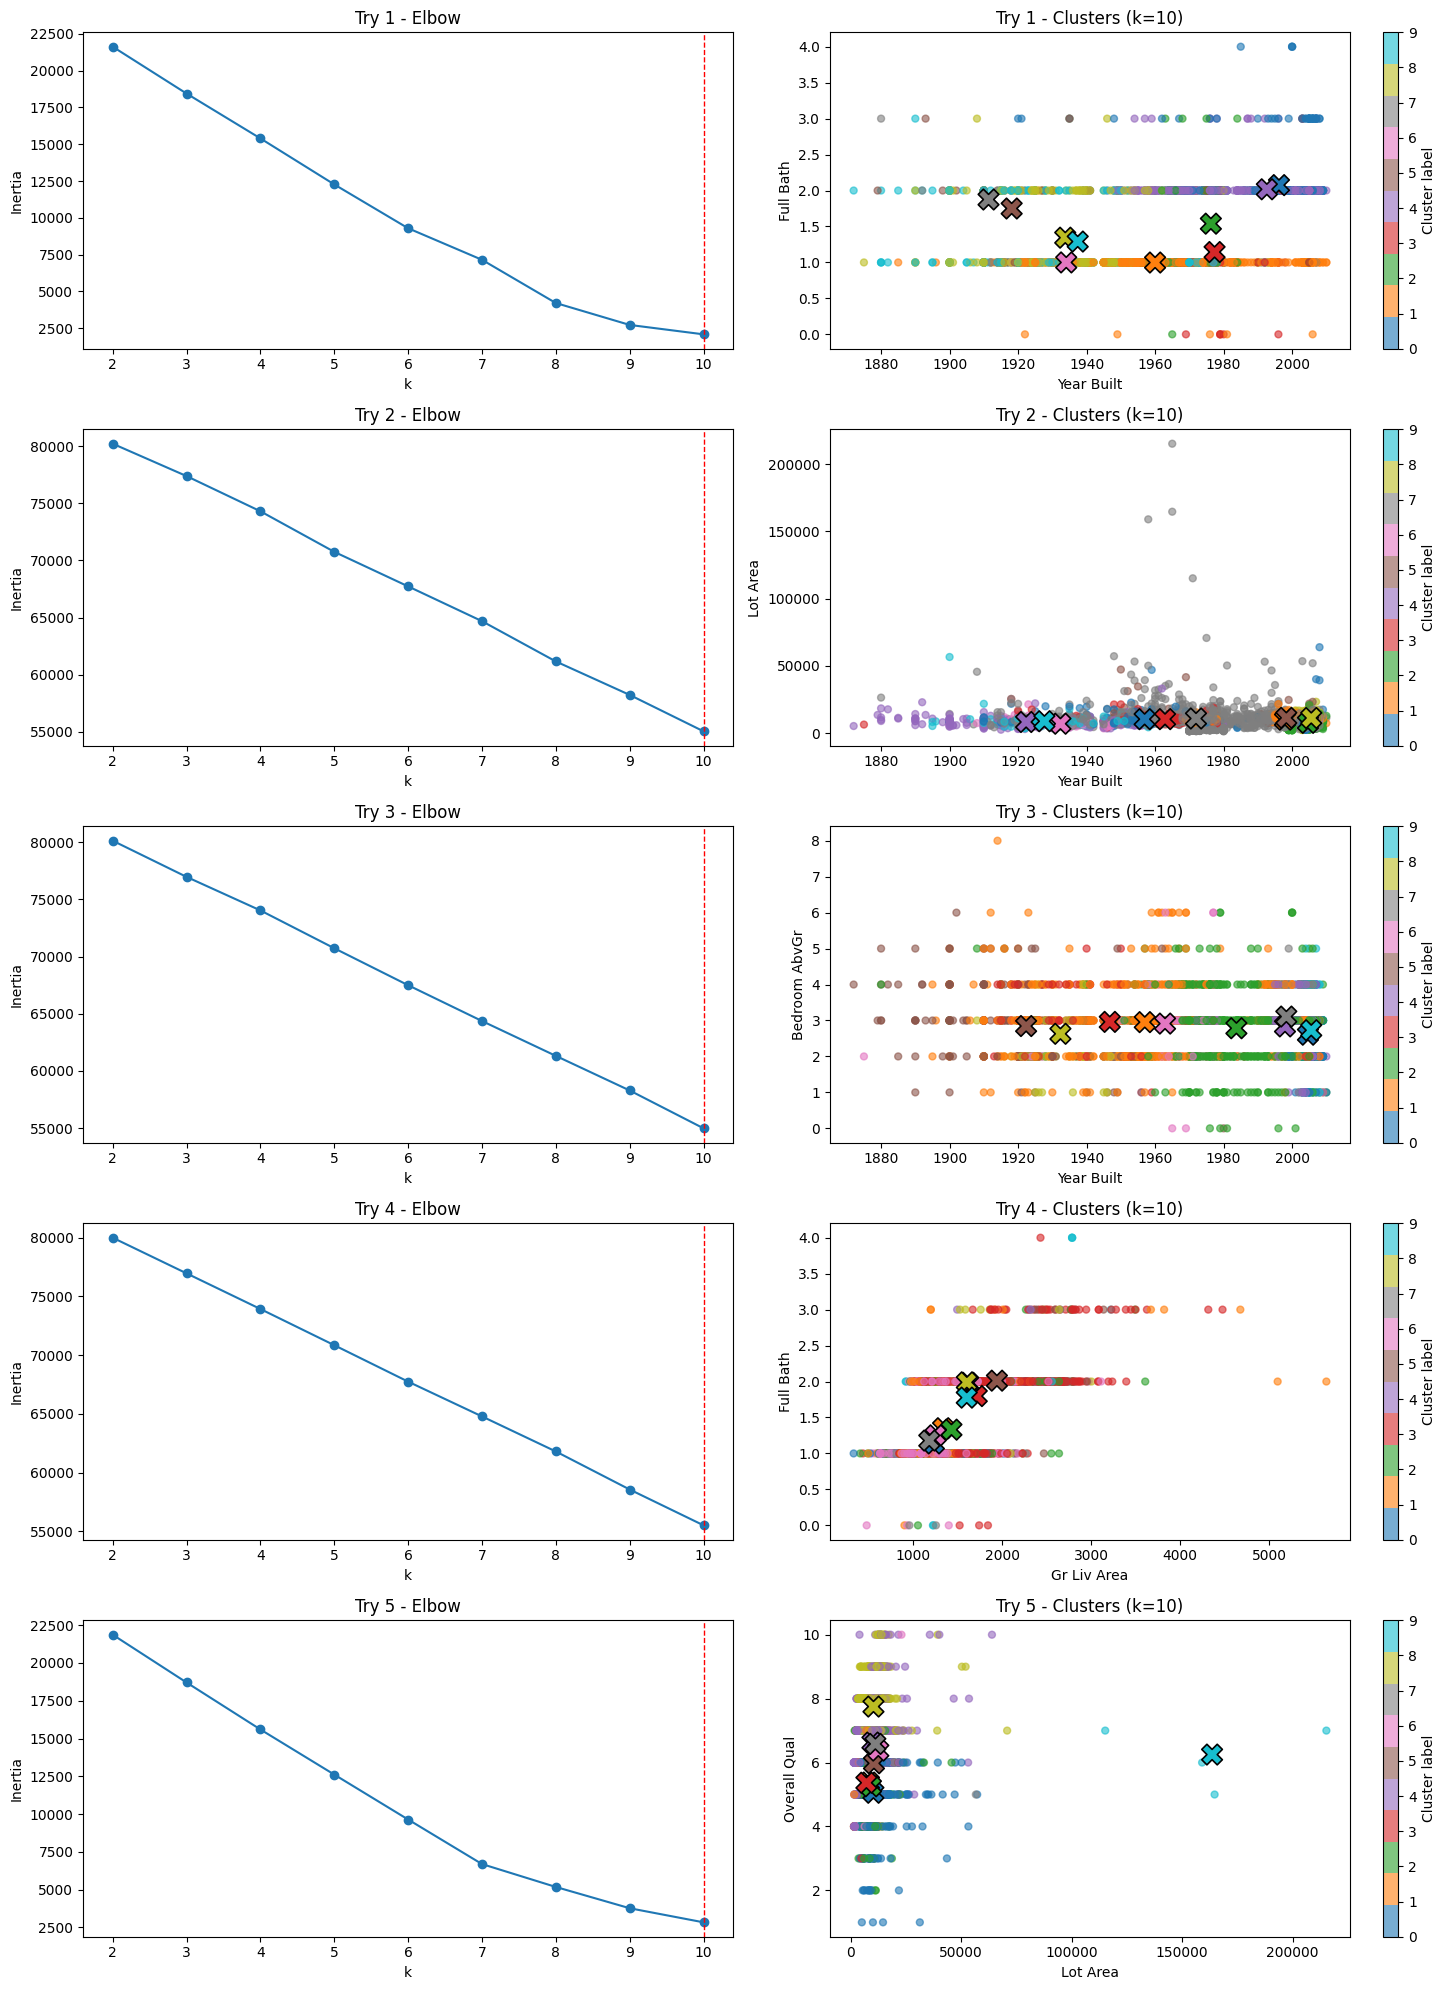

In [19]:
num_runs = len(results)
fig, axes = plt.subplots(num_runs, 2, figsize=(15, max(5, 4 * num_runs)))

if num_runs == 1:
    axes = np.array([axes])

for row_idx, run in enumerate(results):
    ax_elbow = axes[row_idx, 0]
    ax_cluster = axes[row_idx, 1]

    # Elbow graph
    ax_elbow.plot(run["k_values"], run["inertias"], marker="o")
    ax_elbow.axvline(run["best_k"], color="red", linestyle="--", linewidth=1)
    ax_elbow.set_title(f"Try {run['dataset_index']} - Elbow")
    ax_elbow.set_xlabel("k")
    ax_elbow.set_ylabel("Inertia")

    # Cluster graph (first 2 features)
    x_col, y_col = run["features"][0], run["features"][1]
    plot_df = run["data"].copy()
    plot_df["cluster"] = run["labels"]

    scatter = ax_cluster.scatter(
        plot_df[x_col],
        plot_df[y_col],
        c=plot_df["cluster"],
        cmap="tab10",
        alpha=0.6,
        s=25,
    )

    # Colored cluster centers (same colormap)
    centers_df = run["centers_df"]
    center_colors = centers_df["cluster"].values
    ax_cluster.scatter(
        centers_df[x_col],
        centers_df[y_col],
        c=center_colors,
        cmap="tab10",
        marker="X",
        s=220,
        edgecolor="black",
        linewidth=1.2,
        zorder=5,
    )

    ax_cluster.set_title(f"Try {run['dataset_index']} - Clusters (k={run['best_k']})")
    ax_cluster.set_xlabel(x_col)
    ax_cluster.set_ylabel(y_col)

    cbar = fig.colorbar(scatter, ax=ax_cluster)
    cbar.set_label("Cluster label")

plt.tight_layout()
plt.show()

## Distance series and mean distance per cluster

In [20]:
distance_series_list = []
distance_mean_list = []

for run in results:
    distance_series_df = run["distance_series"].rename("distance_to_center").to_frame()
    distance_series_df["dataset_index"] = run["dataset_index"]
    distance_series_df["cluster"] = run["labels"]
    distance_series_df["sample_index"] = distance_series_df.index
    distance_series_list.append(distance_series_df.reset_index(drop=True))

    mean_df = run["distance_mean"].reset_index()
    mean_df.insert(0, "dataset_index", run["dataset_index"])
    distance_mean_list.append(mean_df)

distance_series_all = pd.concat(distance_series_list, ignore_index=True)
distance_means_all = pd.concat(distance_mean_list, ignore_index=True)

print("Distance series (first 15 rows)")
display(distance_series_all.head(15))

print("Mean distance per cluster")
display(distance_means_all)

Distance series (first 15 rows)


,distance_to_center,dataset_index,cluster,sample_index
0,0.002282,1,1,0
1,0.033354,1,1,1
2,0.065969,1,1,2
3,0.815338,1,4,3
4,0.138799,1,0,4
5,0.148947,1,0,5
6,0.279902,1,4,6
7,0.045592,1,4,7
8,0.088416,1,4,8
9,0.165205,1,0,9


Mean distance per cluster


,dataset_index,cluster,mean_distance
0,1,0,0.438001
1,1,1,0.523002
2,1,2,1.096753
3,1,3,0.790075
4,1,4,0.538795
5,1,5,1.137107
6,1,6,0.346625
7,1,7,1.011794
8,1,8,1.004193
9,1,9,1.201710


## Cluster centers dataframe and center colors

In [21]:
cluster_centers_all = pd.concat([run["centers_df"] for run in results], ignore_index=True)

# Keep a stable color label for each center based on cluster id
cluster_centers_all["center_color"] = cluster_centers_all["cluster"].map(
    lambda c: f"tab:{['blue','orange','green','red','purple','brown','pink','gray','olive','cyan'][c % 10]}"
)

cluster_centers_all.head(20)

,dataset_index,cluster,Year Built,Full Bath,House Style_1.5Unf,House Style_1Story,House Style_2.5Fin,House Style_2.5Unf,House Style_2Story,House Style_SFoyer,...,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Bedroom AbvGr,Gr Liv Area,Overall Qual,center_color
0,1,0,1996.164800,2.075200,8.673617e-19,4.440892e-16,8.673617e-19,1.734723e-18,1.000000e+00,-3.469447e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:blue
1,1,1,1959.993719,0.998744,1.734723e-18,1.000000e+00,1.301043e-18,6.938894e-18,-3.330669e-16,6.938894e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:orange
2,1,2,1976.281250,1.539062,8.673617e-19,-1.110223e-16,-1.301043e-18,1.734723e-18,-5.551115e-17,6.938894e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:green
3,1,3,1977.361446,1.144578,0.000000e+00,-2.220446e-16,-8.673617e-19,1.734723e-18,-5.551115e-17,1.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:red
4,1,4,1992.625360,2.017291,4.336809e-18,9.870317e-01,1.301043e-18,6.938894e-18,-3.330669e-16,3.469447e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:purple
5,1,5,1918.125000,1.750000,8.673617e-19,0.000000e+00,-4.336809e-19,1.000000e+00,5.551115e-17,3.469447e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:brown
6,1,6,1934.052632,1.000000,1.000000e+00,-1.110223e-16,-4.336809e-19,1.734723e-18,0.000000e+00,6.938894e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:pink
7,1,7,1911.375000,1.875000,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-3.469447e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:gray
8,1,8,1933.763934,1.344262,1.734723e-18,-1.110223e-16,8.673617e-19,3.469447e-18,-2.220446e-16,3.469447e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:olive
9,1,9,1937.411290,1.290323,8.673617e-19,-1.110223e-16,4.336809e-19,5.204170e-18,1.000000e+00,6.938894e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:cyan


In [22]:
# Optional: show one detailed run with silhouette values over k
best_run = max(results, key=lambda r: max(r["silhouettes"]))

silhouette_df = pd.DataFrame({
    "k": best_run["k_values"],
    "silhouette": best_run["silhouettes"],
})

print(f"Best run: try {best_run['dataset_index']}")
print(f"Features (first 6): {best_run['features'][:6]}")
print(f"Best k: {best_run['best_k']}")

display(silhouette_df)

Best run: try 1
Features (first 6): ['Year Built', 'Full Bath', 'House Style_1.5Unf', 'House Style_1Story', 'House Style_2.5Fin', 'House Style_2.5Unf']
Best k: 10


,k,silhouette
0,2,0.341090
1,3,0.404537
2,4,0.429125
3,5,0.481117
4,6,0.494647
5,7,0.515720
6,8,0.541041
7,9,0.620031
8,10,0.654540
